Project to check wheather they are eligible or not to get legal aid

libraries

In [761]:
import pandas as pd
import numpy as np
# from sklearn.preprocessing import 
import matplotlib.pyplot as plt
import seaborn as sn
from IPython.display import display
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,f1_score,accuracy_score,recall_score,precision_score,roc_auc_score


Data cleaning

In [762]:
df= pd.read_csv("project_data.csv")
df.head()

,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,7,Risk of Violence,-2.84,2,Low,New,1,0
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,8,Risk of Recidivism,-1.50,1,Low,New,1,0


In [763]:
df.shape

(60843, 28)

In [764]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60843 entries, 0 to 60842
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                60843 non-null  int64  
 1   AssessmentID             60843 non-null  int64  
 2   Case_ID                  60843 non-null  int64  
 3   Agency_Text              60843 non-null  object 
 4   LastName                 60843 non-null  object 
 5   FirstName                60843 non-null  object 
 6   MiddleName               15624 non-null  object 
 7   Sex_Code_Text            60843 non-null  object 
 8   Ethnic_Code_Text         60843 non-null  object 
 9   DateOfBirth              60843 non-null  object 
 10  ScaleSet_ID              60843 non-null  int64  
 11  ScaleSet                 60843 non-null  object 
 12  AssessmentReason         60843 non-null  object 
 13  Language                 60843 non-null  object 
 14  LegalStatus           

In [765]:
df.dtypes

Person_ID                    int64
AssessmentID                 int64
Case_ID                      int64
Agency_Text                 object
LastName                    object
FirstName                   object
MiddleName                  object
Sex_Code_Text               object
Ethnic_Code_Text            object
DateOfBirth                 object
ScaleSet_ID                  int64
ScaleSet                    object
AssessmentReason            object
Language                    object
LegalStatus                 object
CustodyStatus               object
MaritalStatus               object
Screening_Date              object
RecSupervisionLevel          int64
RecSupervisionLevelText     object
Scale_ID                     int64
DisplayText                 object
RawScore                   float64
DecileScore                  int64
ScoreText                   object
AssessmentType              object
IsCompleted                  int64
IsDeleted                    int64
dtype: object

RawScore = the original numerical score calculated from a person's responses, history, and risk factors.
DecileScore = a normalized version of that score, usually converted to a scale from 1 to 10.

Removing all unwanted columns such as ID, name..etc,

In [766]:
df=df.drop(["Person_ID","AssessmentID","Case_ID","FirstName","LastName","MiddleName","IsDeleted","IsCompleted",
"ScaleSet_ID","Scale_ID","AssessmentType"],axis=1)
df.head()

,Agency_Text,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,ScaleSet,AssessmentReason,Language,LegalStatus,CustodyStatus,MaritalStatus,Screening_Date,RecSupervisionLevel,RecSupervisionLevelText,DisplayText,RawScore,DecileScore,ScoreText
0,PRETRIAL,Male,Caucasian,12/05/92,Risk and Prescreen,Intake,English,Pretrial,Jail Inmate,Single,1/1/13 0:00,1,Low,Risk of Violence,-2.08,4,Low
1,PRETRIAL,Male,Caucasian,12/05/92,Risk and Prescreen,Intake,English,Pretrial,Jail Inmate,Single,1/1/13 0:00,1,Low,Risk of Recidivism,-1.06,2,Low
2,PRETRIAL,Male,Caucasian,12/05/92,Risk and Prescreen,Intake,English,Pretrial,Jail Inmate,Single,1/1/13 0:00,1,Low,Risk of Failure to Appear,15.00,1,Low
3,PRETRIAL,Male,Caucasian,09/16/84,Risk and Prescreen,Intake,English,Pretrial,Jail Inmate,Married,1/1/13 0:00,1,Low,Risk of Violence,-2.84,2,Low
4,PRETRIAL,Male,Caucasian,09/16/84,Risk and Prescreen,Intake,English,Pretrial,Jail Inmate,Married,1/1/13 0:00,1,Low,Risk of Recidivism,-1.50,1,Low


Checking for impoute & duplicates in the dataset

In [767]:
df.isnull().sum()

Agency_Text                 0
Sex_Code_Text               0
Ethnic_Code_Text            0
DateOfBirth                 0
ScaleSet                    0
AssessmentReason            0
Language                    0
LegalStatus                 0
CustodyStatus               0
MaritalStatus               0
Screening_Date              0
RecSupervisionLevel         0
RecSupervisionLevelText     0
DisplayText                 0
RawScore                    0
DecileScore                 0
ScoreText                  45
dtype: int64

In [768]:
numeric_col=df.select_dtypes(include=np.number).columns
categorical_col=df.select_dtypes(exclude=np.number).columns

print(numeric_col)
print(categorical_col)

Index(['RecSupervisionLevel', 'RawScore', 'DecileScore'], dtype='object')
Index(['Agency_Text', 'Sex_Code_Text', 'Ethnic_Code_Text', 'DateOfBirth',
       'ScaleSet', 'AssessmentReason', 'Language', 'LegalStatus',
       'CustodyStatus', 'MaritalStatus', 'Screening_Date',
       'RecSupervisionLevelText', 'DisplayText', 'ScoreText'],
      dtype='object')


In [769]:
for col in categorical_col:
    if df[col].isnull().sum():
        df[col]=df[col].fillna(df[col].mode()[0])

In [770]:
df.isnull().sum()

Agency_Text                0
Sex_Code_Text              0
Ethnic_Code_Text           0
DateOfBirth                0
ScaleSet                   0
AssessmentReason           0
Language                   0
LegalStatus                0
CustodyStatus              0
MaritalStatus              0
Screening_Date             0
RecSupervisionLevel        0
RecSupervisionLevelText    0
DisplayText                0
RawScore                   0
DecileScore                0
ScoreText                  0
dtype: int64

In [771]:
df.duplicated().sum()

np.int64(77)

In [772]:
df.drop_duplicates(inplace=True)

In [773]:
df.duplicated().sum()

np.int64(0)

Convert Categorical values to numeric values

In [774]:
le=LabelEncoder()
for col in categorical_col:
    df[col]=le.fit_transform(df[col])
df.head()

,Agency_Text,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,ScaleSet,AssessmentReason,Language,LegalStatus,CustodyStatus,MaritalStatus,Screening_Date,RecSupervisionLevel,RecSupervisionLevelText,DisplayText,RawScore,DecileScore,ScoreText
0,2,1,4,9648,1,0,0,5,0,4,0,1,1,2,-2.08,4,1
1,2,1,4,9648,1,0,0,5,0,4,0,1,1,1,-1.06,2,1
2,2,1,4,9648,1,0,0,5,0,4,0,1,1,0,15.00,1,1
3,2,1,4,7298,1,0,0,5,0,1,0,1,1,2,-2.84,2,1
4,2,1,4,7298,1,0,0,5,0,1,0,1,1,1,-1.50,1,1


In [775]:
for col in numeric_col:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR=q3-q1

    lower_bound=q1-1.5*IQR
    upper_bound=q3+1.5*IQR

    outliners=df[(df[col]<lower_bound) | (df[col]>upper_bound)]

print(outliners)

Empty DataFrame
Columns: [Agency_Text, Sex_Code_Text, Ethnic_Code_Text, DateOfBirth, ScaleSet, AssessmentReason, Language, LegalStatus, CustodyStatus, MaritalStatus, Screening_Date, RecSupervisionLevel, RecSupervisionLevelText, DisplayText, RawScore, DecileScore, ScoreText]
Index: []


Data visualization

<Axes: >

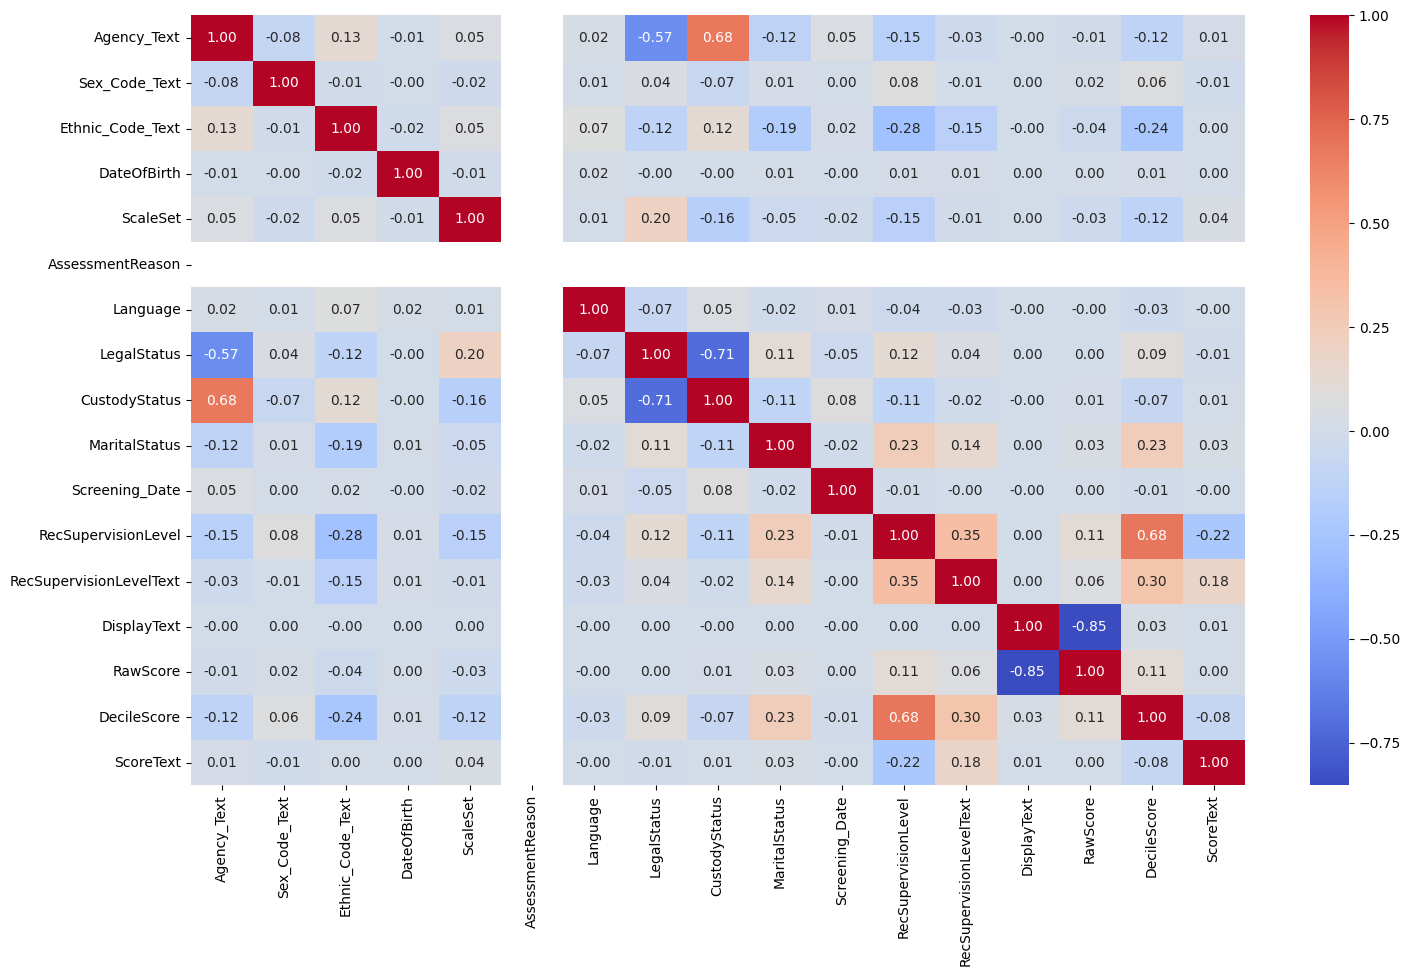

In [776]:
plt.figure(figsize=(17,10))
sn.heatmap(df.corr(numeric_only=True),
            annot=True,
            fmt=".2f",
            cmap="coolwarm"    
            )   

In [777]:
drop_cols=["AssessmentReason","ScaleSet","DisplayText","Language","Agency_Text","Screening_Date"]
df=df.drop(drop_cols,axis=1)

In [778]:
display(df.head())

,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,LegalStatus,CustodyStatus,MaritalStatus,RecSupervisionLevel,RecSupervisionLevelText,RawScore,DecileScore,ScoreText
0,1,4,9648,5,0,4,1,1,-2.08,4,1
1,1,4,9648,5,0,4,1,1,-1.06,2,1
2,1,4,9648,5,0,4,1,1,15.00,1,1
3,1,4,7298,5,0,1,1,1,-2.84,2,1
4,1,4,7298,5,0,1,1,1,-1.50,1,1


Changing Date of birth to Age

In [779]:
df["Age"]=2026-pd.to_datetime(df["DateOfBirth"]).dt.year
df.drop(columns=["DateOfBirth"],inplace=True)

In [780]:
df.head()

,Sex_Code_Text,Ethnic_Code_Text,LegalStatus,CustodyStatus,MaritalStatus,RecSupervisionLevel,RecSupervisionLevelText,RawScore,DecileScore,ScoreText,Age
0,1,4,5,0,4,1,1,-2.08,4,1,56
1,1,4,5,0,4,1,1,-1.06,2,1,56
2,1,4,5,0,4,1,1,15.00,1,1,56
3,1,4,5,0,1,1,1,-2.84,2,1,56
4,1,4,5,0,1,1,1,-1.50,1,1,56


In [781]:
df.to_csv("Project_clean_data.csv",index=False)
print("CSV file saved successfully")

CSV file saved successfully


Feature Scaling

In [782]:
df=pd.read_csv("Project_clean_data.csv")
df.head()

,Sex_Code_Text,Ethnic_Code_Text,LegalStatus,CustodyStatus,MaritalStatus,RecSupervisionLevel,RecSupervisionLevelText,RawScore,DecileScore,ScoreText,Age
0,1,4,5,0,4,1,1,-2.08,4,1,56
1,1,4,5,0,4,1,1,-1.06,2,1,56
2,1,4,5,0,4,1,1,15.00,1,1,56
3,1,4,5,0,1,1,1,-2.84,2,1,56
4,1,4,5,0,1,1,1,-1.50,1,1,56


In [783]:
numeric_col=df.select_dtypes(include=np.number).columns
print(numeric_col)

Index(['Sex_Code_Text', 'Ethnic_Code_Text', 'LegalStatus', 'CustodyStatus',
       'MaritalStatus', 'RecSupervisionLevel', 'RecSupervisionLevelText',
       'RawScore', 'DecileScore', 'ScoreText', 'Age'],
      dtype='object')


In [784]:
minmax=MinMaxScaler()
X=df.drop("ScoreText",axis=1)
y=df["ScoreText"]
df.head()

,Sex_Code_Text,Ethnic_Code_Text,LegalStatus,CustodyStatus,MaritalStatus,RecSupervisionLevel,RecSupervisionLevelText,RawScore,DecileScore,ScoreText,Age
0,1,4,5,0,4,1,1,-2.08,4,1,56
1,1,4,5,0,4,1,1,-1.06,2,1,56
2,1,4,5,0,4,1,1,15.00,1,1,56
3,1,4,5,0,1,1,1,-2.84,2,1,56
4,1,4,5,0,1,1,1,-1.50,1,1,56


In [785]:
df.dtypes

Sex_Code_Text                int64
Ethnic_Code_Text             int64
LegalStatus                  int64
CustodyStatus                int64
MaritalStatus                int64
RecSupervisionLevel          int64
RecSupervisionLevelText      int64
RawScore                   float64
DecileScore                  int64
ScoreText                    int64
Age                          int64
dtype: object

In [786]:
from sklearn.feature_selection import SelectKBest, f_classif

selector= SelectKBest(score_func=f_classif,k=5)
X_tokeep=X.columns[(X.nunique()>1)| (X.columns == 'Age')]
X=X[X_tokeep]
y=df["ScoreText"]

x_new=selector.fit_transform(X,y)
selector_cols=X.columns[selector.get_support()]

print(selector_cols)
print(selector.scores_)

Index(['Ethnic_Code_Text', 'MaritalStatus', 'RecSupervisionLevel',
       'RecSupervisionLevelText', 'DecileScore'],
      dtype='object')
[1.38870991e+02 1.47198392e+03 2.22333557e+02 1.55254263e+02
 1.11497228e+03 2.80065470e+04 4.04095046e+03 2.77903348e+02
 1.77468670e+05            nan]


c:\Users\Sharoon Antony\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [9] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Sharoon Antony\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [787]:
print(X)

       Sex_Code_Text  Ethnic_Code_Text  LegalStatus  CustodyStatus  \
0                  1                 4            5              0   
1                  1                 4            5              0   
2                  1                 4            5              0   
3                  1                 4            5              0   
4                  1                 4            5              0   
...              ...               ...          ...            ...   
60761              1                 1            5              0   
60762              1                 1            5              0   
60763              1                 4            5              0   
60764              1                 4            5              0   
60765              1                 4            5              0   

       MaritalStatus  RecSupervisionLevel  RecSupervisionLevelText  RawScore  \
0                  4                    1                        1     -2.08   

In [788]:
print('Age' in X.columns)

True


In [789]:
print(y)

0        1
1        1
2        1
3        1
4        1
        ..
60761    0
60762    0
60763    1
60764    2
60765    1
Name: ScoreText, Length: 60766, dtype: int64


In [790]:
print(X.shape)
print(y.shape)

(60766, 10)
(60766,)


In [791]:
from sklearn.decomposition import PCA
pca=PCA(n_components=5)
x_pca=pca.fit_transform(X)

print(x_pca)


[[-7.15085738  0.50565173 -1.11278816  1.78562274  0.62884846]
 [-6.19400315 -1.28404245 -1.7299046   1.30702542  0.87706338]
 [ 9.82482539 -2.71078021 -2.15164344  1.07773197  0.99718842]
 ...
 [-7.88295996 -1.22623568 -1.71760394  1.30593804  0.8774962 ]
 [-5.38067335  1.32353714 -0.82060656  2.0263691   0.50416476]
 [10.8554662  -1.86758296 -1.85407575  1.3180022   0.87269424]]


Testing and Training

In [792]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,shuffle=True,random_state=42)

In [793]:
print(xtrain.shape)
print(ytrain.shape)

(48612, 10)
(48612,)


Logistic Regression

In [794]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(xtrain,ytrain)
print(lr.coef_,lr.intercept_)
print(lr.classes_)


[[ 2.56290287e-02  1.28202477e-01 -1.00993252e-01 -9.45889240e-03
  -2.37425717e-02  5.12431268e-01 -5.94839380e-02  3.55939011e-02
   1.09951012e+01 -1.26472573e+00]
 [-1.06333302e-01 -1.58707193e-01  1.04376255e-01  2.21578920e-02
   1.88636476e-01 -6.28106376e-01  1.90226570e-01 -3.96294979e-02
  -1.18511861e+01  1.13917763e+00]
 [ 8.07042732e-02  3.05047164e-02 -3.38300285e-03 -1.26989996e-02
  -1.64893904e-01  1.15675109e-01 -1.30742632e-01  4.03559682e-03
   8.56084962e-01  1.25548106e-01]] [-0.02363683  0.02148428  0.00215256]
[0 1 2]


c:\Users\Sharoon Antony\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Naive Bayes

In [795]:
gnb=GaussianNB()
gnb.fit(xtrain,ytrain)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [796]:

import pickle

with open("naive_bayes1.pkl","wb") as file:
    pickle.dump(gnb, file)

print("Naive Bayes model saved")

Naive Bayes model saved


In [797]:
ypred=gnb.predict(xtest)
print(confusion_matrix(ytest,ypred))

[[1255    0   47]
 [   0 8011  316]
 [  17  127 2381]]


In [798]:
y_prob=gnb.predict_proba(xtest)
print("Accuracy: ",accuracy_score(ytest,ypred))
print("Precision: ",precision_score(ytest,ypred,average="macro"))
print("Recall: ",recall_score(ytest,ypred,average="macro"))
print("F1 Score: ",f1_score(ytest,ypred,average="macro"))
print("Roc_auc_score: ",roc_auc_score(ytest,y_prob,multi_class="ovr"))

Accuracy:  0.9582853381602765
Precision:  0.9462469301457763
Recall:  0.9563077152061977
F1 Score:  0.950669075212248
Roc_auc_score:  0.9932030085507391


In [799]:
y_prob=gnb.predict_proba(xtrain)
print("Accuracy: ",accuracy_score(ytest,ypred))
print("Precision: ",precision_score(ytest,ypred,average="macro"))
print("Recall: ",recall_score(ytest,ypred,average="macro"))
print("F1 Score: ",f1_score(ytest,ypred,average="macro"))

Accuracy:  0.9582853381602765
Precision:  0.9462469301457763
Recall:  0.9563077152061977
F1 Score:  0.950669075212248


In [800]:
display(df)

,Sex_Code_Text,Ethnic_Code_Text,LegalStatus,CustodyStatus,MaritalStatus,RecSupervisionLevel,RecSupervisionLevelText,RawScore,DecileScore,ScoreText,Age
0,1,4,5,0,4,1,1,-2.08,4,1,56
1,1,4,5,0,4,1,1,-1.06,2,1,56
2,1,4,5,0,4,1,1,15.00,1,1,56
3,1,4,5,0,1,1,1,-2.84,2,1,56
4,1,4,5,0,1,1,1,-1.50,1,1,56
...,...,...,...,...,...,...,...,...,...,...,...
60761,1,1,5,0,4,3,3,0.16,8,0,56
60762,1,1,5,0,4,3,3,35.00,10,0,56
60763,1,4,5,0,4,1,1,-2.75,2,1,56
60764,1,4,5,0,4,1,1,-0.34,5,2,56
